# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Happy Ending Forever
- **Email:** hepindut216@gmail.com
- **ID Dicoding:** CDCC889D6Y0613

## Menentukan Pertanyaan Bisnis

**Pertanyaan 1:**
  - Bagaimana perbedaan perilaku penyewaan antara pengguna Casual dan Registered pada hari kerja (Working Day) dibandingkan dengan hari libur sepanjang periode 2011-2012?
  - Keterangan:
    * Specific: Fokus ke perbandingan pada dua segmen pengguna (Casual dan Registered) dan dua tipe hari (Hari Kerja dan Hari Libur).
    * Measurable: Dapat diukur dengan angka rata-rata penyewaan (casual dan registered) yang ada di dalam dataset.
    * Actionable: Hasilnya dapat digunakan untuk menentukan strategi distribusi armada sepeda di lokasi yang berbeda (perkantoran vs tempat wisata).
    * Relevant: Memahami segmentasi pasar adalah kunci utama untuk meningkatkan loyalitas pengguna.
    * Time-bound: Analisis dibatasi pada periode data tahun 2011-2012.

**Pertanyaan 2:**
  - Sejauh mana kondisi cuaca (Cerah, Berkabut, Hujan Ringan) memengaruhi rata-rata jumlah penyewaan sepeda harian pada tahun 2012?
  - Keterangan:
    * Specific: Fokus secara mendalam pada variabel kondisi cuaca (weathersit) yang dibagi menjadi tiga kategori utama (Cerah, Berkabut, Hujan).
    * Measurable: Dampak cuaca diukur berdasarkan nilai rata-rata total penyewaan (cnt) harian.
    * Actionable: Perusahaan dapat membuat program promosi atau manajemen risiko operasional saat kondisi cuaca memburuk.
    * Relevant: Cuaca adalah faktor eksternal paling krusial yang memengaruhi bisnis transportasi luar ruangan.
    * Time-bound: Fokus pengamatan dilakukan secara spesifik pada data tahun 2012.

**Pertanyaan 3:**
  - Apakah terdapat perbedaan pola waktu menyewa sepeda antara pengguna Casual dan Registered berdasarkan kategori waktu pada hari kerja?
  - Keterangan:
    * Specific: Fokus pada pola penggunaan berdasarkan jam yang sudah dikelompokkan (binning).
    * Measurable: Perbedaan dihitung melalui rata-rata jumlah penyewaan per jam untuk masing-masing tipe pengguna.
    * Actionable: Memberikan data yang konkret untuk menentukan jadwal pemeliharaan sepeda (maintenance) agar tidak mengganggu jam tersibuk.
    * Relevant: Optimalisasi jadwal operasional sangat penting untuk efisiensi biaya perusahaan.
    * Time-bound: Analisis difokuskan pada pola harian (jam) selama hari kerja yang tercatat dalam dataset.

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
df_hari = pd.read_csv('\data\day.csv')
df_jam = pd.read_csv('\data\hour.csv')

print("data per-hari")
print(df_hari.head())
print("=============")
print("data per-jam")
print(df_jam.head())

data per-hari
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  
data per-jam

In [3]:
df_hari.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
df_jam.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Terdapat 2 dataset yakni day.csv merupakan data peminjaman sepeda yang dikumpulkan dengan rentang per-hari, selain itu ada hour.csv merupakan data peminjaman sepeda yang dikumpulkan per-jam
- Dataset day.csv sendiri memiliki 16 kolom mencakup:
  *   instant = index
  *   dteday = tanggal peminjaman
  *   season = musim(spring(1), summer(2), fall(3), winter(4))
  *   yr = tahun(2011(0), 2012(1))
  *   mnth = index bulan
  *   holiday = hari libur(ya/tidak)
  *   weekday = hari(minggu(0), senin(1), dst...)
  *   workingday = hari kerja(ya/tidak)
  *   weathersit = kondisi cuaca(cerah(1), kabut(2), hujan ringan(3), hujan lebat(4))
  *   temp = suhu udara yang ternormalisasi
  *   atemp = suhu yang dirasakan ternomalisasi
  *   hum = kelembapan udara ternormalisasi
  *   windspeed = kecepatan angin ternormalisasi
  *   casual = jumlah penyewa non-member
  *   registered = jumlah penyewa member
  *   cnt = total penyewa(casual + registered)
- Dataset hour.csv memiliki kolom yang sama, hanya berbeda pada hour.csv terdapat kolom hr(index jam (0-23))
- note: data pengamatan suhu dinormalisasi dengan cara dibagi dengan nilai tertentu, seperti temp 41, atemp 50, hum 100, dan windspeed 67


### Assessing Data

#### Identifying ... problem

**data df_hari**

In [5]:
print("CEK MISSING VALUE DAN DUPLIKAT DATA HARI")
print("MISSING:")
print(df_hari.isna().sum())

print("\n")

print("DUPLIKAT:")
print(df_hari.duplicated().sum())

CEK MISSING VALUE DAN DUPLIKAT DATA HARI
MISSING:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


DUPLIKAT:
0


In [6]:
print("CEK TIPE DATA TIAP KOLOM DATA HARI")
df_hari.info()

CEK TIPE DATA TIAP KOLOM DATA HARI
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
print("RINGKASAN STATISTIK DATA HARI")
df_hari.describe()

RINGKASAN STATISTIK DATA HARI


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- mengecek noise (missing value dan duplikat)
- mengecek tipe data tiap kolom
- melihat ringkasan statistik

**Insight:** (Opsional)
- Data bersih tanpa missing value dan duplikat
- Tipe data mayoritas adalah integer(bilangan bulat) dan float(desimal), kolom dteday terbaca sebagai object.
- Ringkasan Statistik:
  *   Rata-rata pengguna Registered(member) mencapai sekitar 3.656 per hari, jauh melampaui pengguna Casual(non-member) yang hanya sekitar 848 per hari.
  *   Rata-rata suhu ternormalisasi berada di angka 0,49 (setara dengan suhu sejuk sekitar 20°C) dengan kelembapan rata-rata 62%. Ideal untuk orang bersepeda.
  *   Data menunjukkan distribusi yang seimbang antara tahun 2011 dan 2012, dengan sekitar 68% data merupakan hari kerja (workingday). Tingginya proporsi hari kerja ini selaras dengan profil pengguna Registered yang dominan, memperkuat dugaan bahwa penggunaan sepeda paling banyak terjadi untuk keperluan mobilitas kerja.
  *   Rentang jumlah penyewaan total (cnt) sangat lebar, mulai dari angka terendah 22 hingga mencapai puncaknya di 8.714 penyewaan dalam satu hari. Mengidikasikan adanya hari dimana peminjaman sepeda sangat sedikit dan ada hari dimana peminjaman sangat banyak.






**data df_jam**

In [8]:
print("CEK MISSING VALUE DAN DUPLIKAT DATA JAM")
print("MISSING:")
print(df_jam.isna().sum())

print("\n")

print("DUPLIKAT:")
print(df_jam.duplicated().sum())

CEK MISSING VALUE DAN DUPLIKAT DATA JAM
MISSING:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


DUPLIKAT:
0


In [9]:
print("CEK TIPE DATA TIAP KOLOM DATA JAM")
df_jam.info()

CEK TIPE DATA TIAP KOLOM DATA JAM
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [10]:
print("RINGKASAN STATISTIK DATA JAM")
df_jam.describe()

RINGKASAN STATISTIK DATA JAM


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:** (Opsional):
- data bersih
- tipe data sama seperti df_hari, kolom hr memiliki tipe data integer karena merupakan index jam(0-23)
- Ringkasan Statistik:
  *   Rata-rata penyewaan per jam berada di angka 189 unit, namun nilai standar deviasinya sangat besar (181), hampir setara dengan rata-ratanya sendiri. Hal ini menunjukkan bahwa permintaan antar jam sangat tidak menentu, ada jam yang sangat sepi 1 sepeda dan ada jam puncak yang sangat sibuk mencapai 977 sepeda, sehingga diperlukan manajemen distribusi armada yang dinamis.
  *   Terdapat jarak yang cukup besar antara nilai minimum dan maksimum pada penyewa Casual dan Registered, dengan minimum 0 dan maksimum Casual 367 sepeda dan Registered 885 sepeda.



### Cleaning Data

#### Fixing ... problem

In [11]:
# Hapus kolom index (instan)
df_hari.drop(columns='instant', inplace=True)
df_jam.drop(columns='instant', inplace=True)

In [12]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Menghapus outlier pada kolom hum dan windspeed di df_hari
df_hari = remove_outliers(df_hari, 'hum')
df_hari_clean = remove_outliers(df_hari, 'windspeed').copy()

# Menghapus outlier pada kolom hum dan windspeed di df_jam
df_jam = remove_outliers(df_jam, 'hum')
df_jam_clean = remove_outliers(df_jam, 'windspeed').copy()

print(f"data hari clean: {len(df_hari_clean)}")
print(f"data jam clean: {len(df_jam_clean)}")

data hari clean: 717
data jam clean: 17016


**Insight:**
- Menghapus kolom index, karena tidak digunakan dalam analisis nantinya.
- Menghapus outlier untuk kolom berpotensi seperti hum dan windspeed karena saat assesing data menunjukan nilai minimum mencapai 0, dengan asumsi terdapat kesalahan pada perhitungan alat yang dipakai.
- Kolom lain seperti casual dan registered tidak dihapus karena terdapat poin untuk menjawab pertanyaan bisnis nantinya, sehingga untuk saat ini belum diperlukan penghapusan.

**Konversi Nilai (Data Preparation)**

In [13]:
# Mengonversi dteday menjadi datetime
df_hari_clean['dteday'] = pd.to_datetime(df_hari_clean['dteday'])
df_jam_clean['dteday'] = pd.to_datetime(df_jam_clean['dteday'])

In [14]:
# Mapping season
df_hari_clean['season'] = df_hari_clean['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

# Mapping weathersit
df_hari_clean['weathersit'] = df_hari_clean['weathersit'].map({
    1: 'Cerah',
    2: 'Berkabut',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
})

# Mapping weekday
df_hari_clean['weekday'] = df_hari_clean['weekday'].map({
    0: 'Sun',
    1: 'Mon',
    2: 'Tue',
    3: 'Wed',
    4: 'Thu',
    5: 'Fri',
    6: 'Sat'
})

# Mapping workingday
df_hari_clean['workingday'] = df_hari_clean['workingday'].map({
    0: 'Tidak',
    1: 'Ya'
})

In [15]:
# Mapping season
df_jam_clean['season'] = df_jam_clean['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

# Mapping weathersit
df_jam_clean['weathersit'] = df_jam_clean['weathersit'].map({
    1: 'Cerah',
    2: 'Berkabut',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
})

# Mapping weekday
df_jam_clean['weekday'] = df_jam_clean['weekday'].map({
    0: 'Sun',
    1: 'Mon',
    2: 'Tue',
    3: 'Wed',
    4: 'Thu',
    5: 'Fri',
    6: 'Sat'
})

# Mapping workingday
df_jam_clean['workingday'] = df_jam_clean['workingday'].map({
    0: 'Tidak',
    1: 'Ya'
})

In [16]:
# Mengembalikan nilai ke skala asli (Denormalisasi)
df_hari_clean['temp'] = df_hari_clean['temp'] * 41
df_hari_clean['atemp'] = df_hari_clean['atemp'] * 50
df_hari_clean['hum'] = df_hari_clean['hum'] * 100
df_hari_clean['windspeed'] = df_hari_clean['windspeed'] * 67

**Insight:**
- mengubah tipe data dteday menjadi datetime agar bisa dipakai untuk analisis
- memberi mapping untuk kolom data kategorik (season, weathersit, weekday)
- melakukakn denormalisasi untuk kolom pengamatan suhu(temp, atemp, hum, windspeed) ke angka semula

## Exploratory Data Analysis (EDA)

### Explore ...

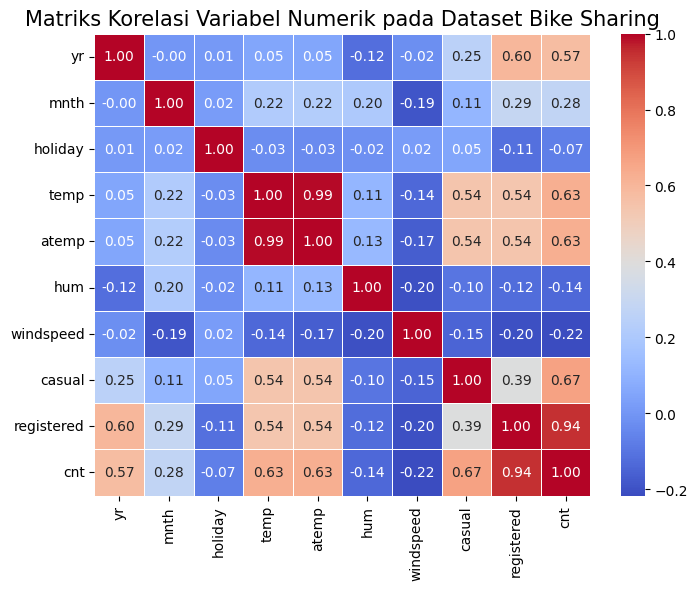

In [17]:
numeric_cols = df_hari_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Variabel Numerik pada Dataset Bike Sharing', fontsize=15)
plt.show()

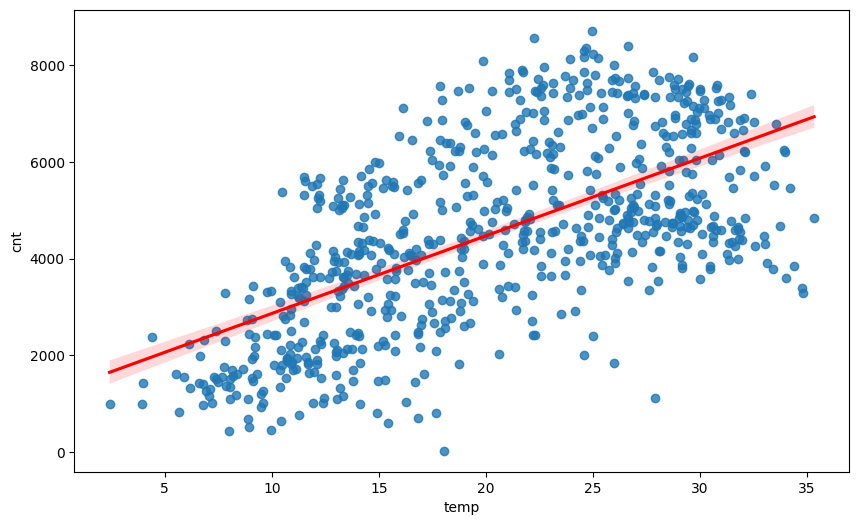

In [18]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_hari_clean,
    x='temp',
    y='cnt',
    line_kws={'color': 'red', 'label': 'Trend Line'}
)
plt.show()

In [19]:
# Grouping berdasarkan workingday untuk melihat rata-rata casual dan registered
user_type_analysis = df_hari_clean.groupby('workingday').agg({
    'casual': 'mean',
    'registered': 'mean',
    'cnt': 'mean'
}).reset_index()

print("Analisis Perbandingan Pengguna di Hari Kerja vs Libur:")
print(user_type_analysis)

Analisis Perbandingan Pengguna di Hari Kerja vs Libur:
  workingday       casual   registered          cnt
0      Tidak  1392.066372  2980.345133  4372.411504
1         Ya   610.635438  3996.052953  4606.688391


In [20]:
# 1. Filter tahun 2012
df_2012 = df_hari_clean[df_hari_clean['yr'] == 1]

# 2. GROUPING (Ini yang tadi hilang!)
weather_impact = df_2012.groupby('weathersit')['cnt'].mean().reset_index()

# 3. Urutkan biar logis (Cerah -> Kabut -> Hujan)
weather_impact = weather_impact.set_index('weathersit').reindex(['Cerah', 'Berkabut', 'Hujan Ringan']).reset_index()

print(weather_impact)

     weathersit          cnt
0         Cerah  6071.683983
1      Berkabut  4999.223140
2  Hujan Ringan  2126.166667


In [21]:
def get_time_category(hour):
    if 6 <= hour < 10: return 'Pagi'
    elif 10 <= hour < 15: return 'Siang'
    elif 15 <= hour < 19: return 'Sore'
    else: return 'Malam'

# 2. Terapkan binning pada data jam
df_jam_clean['time_category'] = df_jam_clean['hr'].apply(get_time_category)

In [22]:
# Grouping berdasarkan kategori waktu pada HARI KERJA
# Kita filter workingday == 1 (Ya)
working_day_pattern = df_jam_clean[df_jam_clean['workingday'] == "Ya"].groupby('time_category').agg({
    'casual': 'mean',
    'registered': 'mean'
}).reindex(['Pagi', 'Siang', 'Sore', 'Malam']).reset_index()

print("Perbandingan Pola Sewa di Hari Kerja:")
print(working_day_pattern)

Perbandingan Pola Sewa di Hari Kerja:
  time_category     casual  registered
0          Pagi  15.773286  262.973388
1         Siang  39.965660  136.099710
2          Sore  50.911261  329.782564
3         Malam  13.507143   88.815226


**Insight:**
- Rata-rata penyewa Casual melunjak ketika hari libur (1392 sepeda) dan turun ketika hari kerja(610 sepeda), sedangkan rata-rata penyewa Registered melunjak ketika hari kerja(3996 sepeda) dibanding di hari libur(2980 sepeda).
- Pada tahun 2012, cuaca menjadi pengaruh yang menentukan banyaknya penyewa pada hari itu, dilihat ketika Cuaca Cerah terdapat 6071 sepeda dipinjam, ketika berkabut terdapat 4999 sepeda dipinjam, ketika hujan ringan hanya ada 2126 sepeda dipinjam, terlihat bahwa semakin buruk cuaca maka semakin sedikit juga penyewa sepeda.
- Perbandingan pola sewa pada hari kerja untuk penyewa Casual dan Registered cukup berbeda, dimana penyewa Casual melunjak ketika jam Siang ke Sore, sedangkan registered mulai melunjak dari Pagi hari lalu turun di Siang hari lalu naik lagi saat sore hari

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana perbedaan perilaku penyewaan antara pengguna Casual dan Registered pada hari kerja (Working Day) dibandingkan dengan hari non-kerja (Non-working Day) sepanjang periode 2011-2012?

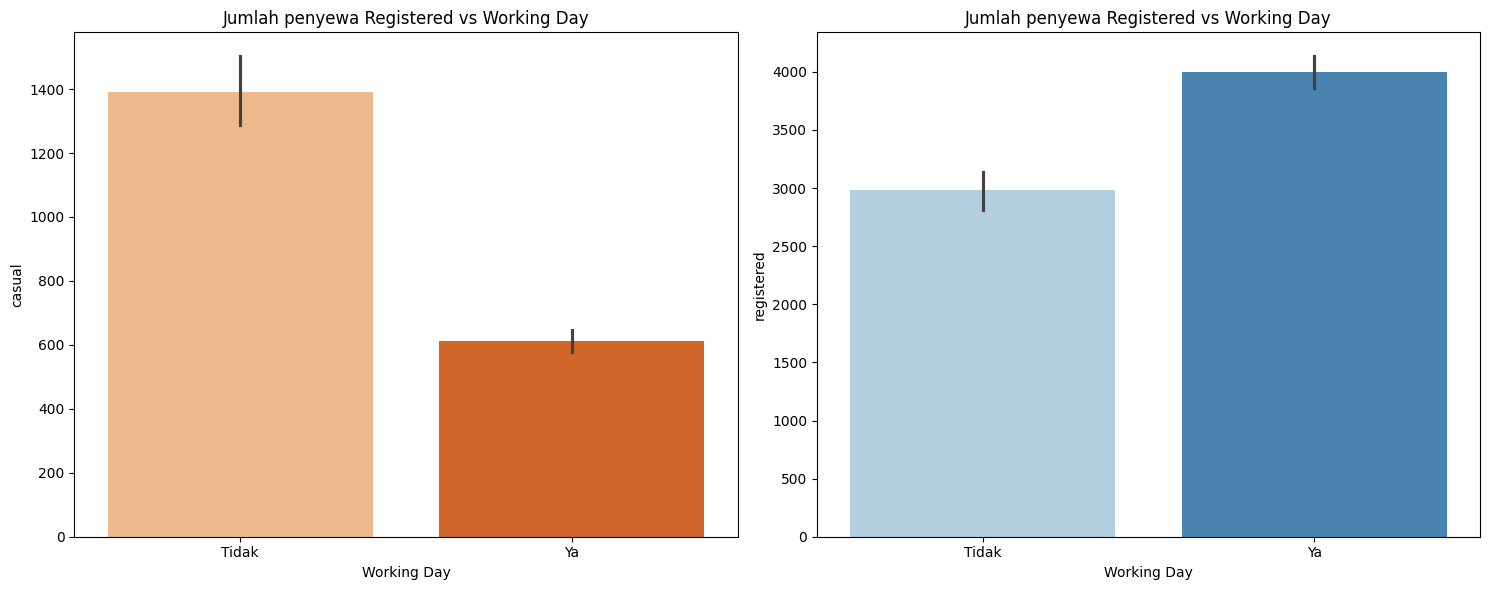

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Barplot Casual
sns.barplot(
    data=df_hari_clean,
    x='workingday',
    y='casual',
    ax=axes[0],
    palette='Oranges',
    hue='workingday',
    legend=False
)
axes[0].set_title('Jumlah penyewa Registered vs Working Day', fontsize=12)
axes[0].set_xlabel('Working Day')

# Barplot Registered
sns.barplot(
    data=df_hari_clean,
    x='workingday',
    y='registered',
    ax=axes[1],
    palette='Blues',
    hue='workingday',
    legend=False
)
axes[1].set_title('Jumlah penyewa Registered vs Working Day', fontsize=12)
axes[1].set_xlabel('Working Day')

plt.tight_layout()
plt.show()

### Pertanyaan 2: Sejauh mana kondisi cuaca (Cerah, Berkabut, Hujan Ringan) memengaruhi rata-rata jumlah penyewaan sepeda harian pada tahun 2012?

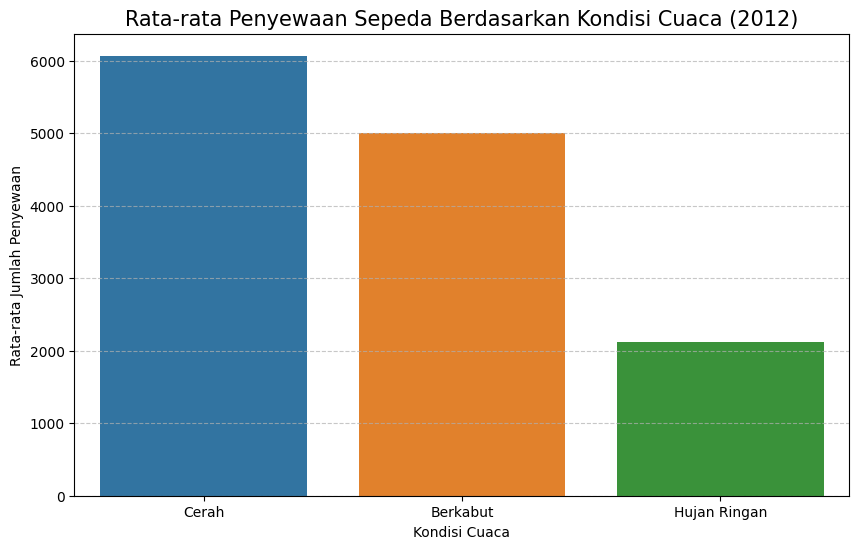

In [24]:
plt.figure(figsize=(10, 6))

# Kita pakai order agar urutannya logis: Cerah -> Berkabut -> Hujan
sns.barplot(
    x='weathersit',
    y='cnt',
    data=weather_impact,
    order=['Cerah', 'Berkabut', 'Hujan Ringan'],
    hue='weathersit'
)

plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2012)', fontsize=15)
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 3: Apakah terdapat perbedaan pola waktu menyewa sepeda antara pengguna Casual dan Registered berdasarkan kategori waktu, khusus pada hari kerja?

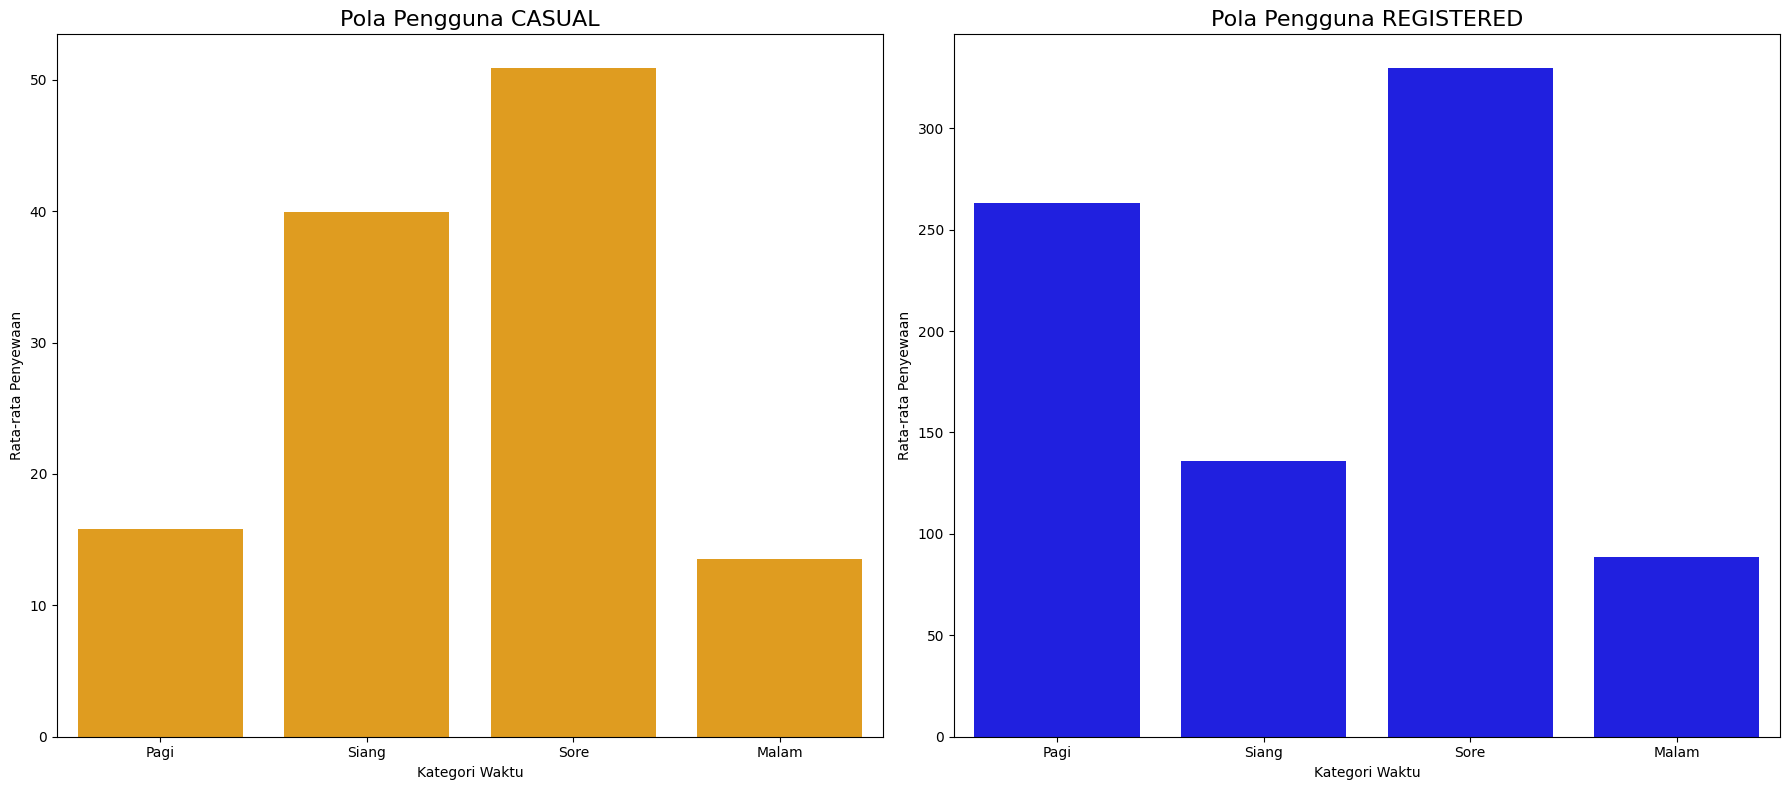

In [25]:
# Membuat kanvas dengan 1 baris dan 2 kolom
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))

# 1. Visualisasi untuk Pengguna CASUAL (Kiri)
sns.barplot(
    data=working_day_pattern,
    x='time_category',
    y='casual',
    ax=axes[0],
    color='orange',
    legend=False
)
axes[0].set_title('Pola Pengguna CASUAL', fontsize=16)
axes[0].set_xlabel('Kategori Waktu')
axes[0].set_ylabel('Rata-rata Penyewaan')

# 2. Visualisasi untuk Pengguna REGISTERED (Kanan)
sns.barplot(
    data=working_day_pattern,
    x='time_category',
    y='registered',
    ax=axes[1],
    color='blue',
    legend=False
)
axes[1].set_title('Pola Pengguna REGISTERED', fontsize=16)
axes[1].set_xlabel('Kategori Waktu')
axes[1].set_ylabel('Rata-rata Penyewaan')

plt.tight_layout()
plt.show()

**Insight:**
1. Dapat dilihat pada Barplot bahwa penyewa Casual lebih banyak menyewa sepeda pada hari libur dibanding hari kerja, sedangkan penyewa registered lebih banyak menyewa sepeda pada hari kerja dibanding pada saat hari libur
2. Jumlah penyewa lebih banyak ketika cuaca cerah dan berkurang ketika cuaca buruk(berkabut dan hujan)
3. Perbandingan pola Casual dan Registered terlihat bahwa penyewa Registered mulai aktif dari pagi hari dengan lonjakan pengguna, sedangkan Casual cenderung naik bertahap. Keduanya memiliki kesamaan pada malam hari yakni terjadi penurunan pengguna

## Conclusion & Recommendation

## Conclusion pertanyaan 1
Berdasarkan analisis data, terdapat perbedaan perilaku yang sangat kontras antara pengguna Casual dan Registered terkait status hari kerja, di mana pengguna Registered sanagt aktif di hari kerja dengan rata-rata penyewaan mencapai (3.996 sepeda) berbanding jauh dengan pengguna Casual yang hanya (610 sepeda). Sebaliknya, pada hari libur, pengguna Casual menunjukkan antusiasme yang melonjak lebih dari dua kali lipat menjadi (1.392 sepeda), sementara pengguna Registered justru mengalami penurunan aktivitas (2980 sepeda). Hal ini membuktikan bahwa segmen Registered menggunakan sepeda untuk keperluan pekerjaan, sedangkan segmen Casual didominasi oleh pengguna rekreasional.



## Conclusion pertanyaan 2:
 Analisis terhadap kondisi cuaca tahun 2012 menunjukkan bahwa cuaca merupakan variabel eksternal yang paling krusial dalam menentukan volume penyewaan, dengan kondisi Cerah sebagai puncaknya yang menyentuh angka rata-rata 6.071 penyewaan per hari. Terjadi penurunan performa yang signifikan saat cuaca berubah menjadi Berkabut, dan anjlok secara drastis hingga 64,98% ketika terjadi Hujan Ringan yang hanya menyisakan rata-rata 2.126 penyewaan. Data ini mengonfirmasi bahwa kenyamanan cuaca menjadi faktor utama yang memengaruhi keputusan pengguna dalam menggunakan moda transportasi sepeda.

## Conclusion pertanyaan 3:
Eksplorasi terhadap kategori waktu pada hari kerja mengungkap adanya fenomena pola waktu yang berbeda secara fundamental; pengguna Registered menunjukkan pola "Double Peak" yang selaras dengan jam berangkat kerja (Pagi: 450 unit) dan jam pulang kerja (Sore: 509 unit). Di sisi lain, pengguna Casual menunjukkan pola "Single Peak" yang jauh lebih landai dengan puncak aktivitas pada periode (Sore: 50), yang menegaskan bahwa mereka tidak terpengaruh oleh tekanan jam sibuk perkotaan dan menggunakan sepeda untuk keperluan yang lebih fleksibel atau santai.

**Rekomendasi Action Item:**
Untuk mengoptimalkan performa bisnis, perusahaan harus menerapkan strategi distribusi armada yang dinamis dengan memprioritaskan area perkantoran di hari kerja dan area wisata di hari libur. Selain itu, perusahaan perlu menangani masalah faktor cuaca dengan fitur promosi otomatis "Rainy Day". Selain itu, manajemen harus menjadwalkan proses pemeliharaan rutin sepeda pada periode Siang di hari kerja untuk meminimalkan gangguan operasional pada jam tersibuk bagi kalangan pekerja, serta mempertimbangkan paket langganan "Weekend Membership" untuk mengonversi tingginya volume pengguna Casual di hari libur menjadi loyalitas jangka panjang.

In [26]:
all_df = pd.merge(
    left=df_jam_clean,
    right=df_hari_clean,
    how="left",
    on="dteday",
    suffixes=("_hour", "_day")
)

all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17016 entries, 0 to 17015
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   dteday           17016 non-null  datetime64[ns]
 1   season_hour      17016 non-null  object        
 2   yr_hour          17016 non-null  int64         
 3   mnth_hour        17016 non-null  int64         
 4   hr               17016 non-null  int64         
 5   holiday_hour     17016 non-null  int64         
 6   weekday_hour     17016 non-null  object        
 7   workingday_hour  17016 non-null  object        
 8   weathersit_hour  17016 non-null  object        
 9   temp_hour        17016 non-null  float64       
 10  atemp_hour       17016 non-null  float64       
 11  hum_hour         17016 non-null  float64       
 12  windspeed_hour   17016 non-null  float64       
 13  casual_hour      17016 non-null  int64         
 14  registered_hour  17016 non-null  int64

In [27]:
all_df.to_csv("all_data.csv", index=False)